In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
%matplotlib widget
from scipy.signal import welch, detrend, csd, coherence, find_peaks
from scipy.linalg import svd
import os

plt.rcParams['font.sans-serif'] = 'Times New Roman'
plt.rcParams['figure.figsize'] = (5, 4.5)
plt.rcParams['figure.dpi'] = 80
plt.rcParams.update({'font.size': 12}) 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyoma2.setup.single import SingleSetup
from pyoma2.algorithms.fdd import FDD

In [3]:
# Obtener solo carpetas
carpetas = [carpeta for carpeta in os.listdir('.') if os.path.isdir(carpeta)]

# Mostrar carpetas
print('Carpetas de data:')
for i, carpeta in enumerate(carpetas):
    print(f'[{i}] --> {carpeta}')

Carpetas de data:
[0] --> DATA_CorreaOverland
[1] --> DATA_PuenteItata
[2] --> DATA_PuenteItata+Tren
[3] --> DATA_PuenteItata+Tren_NEW
[4] --> DATA_PuenteItata_Reposo
[5] --> DATA_PuenteItata_Reposo+Tren+Sismo
[6] --> DATA_PuenteItata_Sismo
[7] --> DATA_PuenteItata_Tren+Sismo
[8] --> Export_Artemis
[9] --> Modelos_TeklaStructures
[10] --> Registros


In [4]:
carpeta_data = carpetas[6]
print(f'Carpeta escogida: {carpeta_data}')

Carpeta escogida: DATA_PuenteItata_Sismo


In [5]:
#data = [archivo for archivo in os.listdir('./DATA_CorreaOverland/') if archivo.endswith(".txt")]
data_all = [archivo for archivo in os.listdir(f'./{carpeta_data}/') if archivo.endswith(".txt")]
for i in range(len(data_all)):
    print('[{}]'.format(i),'-->', data_all[i])

[0] --> Proc_Sismo_20260509_223448.txt


In [6]:
for i in range(len(data_all)):
    df = pd.read_table(f'./{carpeta_data}/{data_all[i]}', decimal=".")
    t_total = (pd.to_datetime(df["Time"].iloc[-1], format="%d-%b-%Y %H:%M:%S")-pd.to_datetime(df["Time"].iloc[0], format="%d-%b-%Y %H:%M:%S")).total_seconds() # Tiempo total
    N = len(df) # Cantidad de muestras 
    fs = N / t_total # Frecuencia de muestreo
    #print(f'Cantidad de datos:\t{N}')
    print(f'{data_all[i]}:\t{N} datos\tfs: {fs:.4f} Hz')

Proc_Sismo_20260509_223448.txt:	23031 datos	fs: 250.3370 Hz


In [7]:
df = pd.read_table(f'./{carpeta_data}/{data_all[i]}', decimal=".")
df

,Time,Ac00_L,Ac00_T,Ac00_V,Ac01_L,Ac01_T,Ac01_V,Ac02_L,Ac02_T,Ac02_V,Ac03_L,Ac03_T,Ac03_V,Ac05_L,Ac05_T,Ac05_V
0,09-May-2026 22:34:21,0.000007,-0.000088,0.000005,0.000100,-0.000400,0.000194,-0.000004,0.000067,0.000095,-0.000105,-0.000176,-0.000187,-6.532500e-05,-0.000449,0.000047
1,09-May-2026 22:34:21,-0.000073,-0.000039,-0.000057,0.000211,-0.000457,-0.000104,0.000037,-0.000015,0.000042,0.000031,-0.000452,0.000179,4.387500e-05,-0.000031,0.000343
2,09-May-2026 22:34:21,-0.000147,-0.000056,0.000177,-0.000020,-0.000475,0.000177,0.000154,-0.000186,0.000139,-0.000102,-0.000171,0.000193,1.998750e-04,0.000055,0.000051
3,09-May-2026 22:34:21,0.000013,-0.000069,0.000098,-0.000044,-0.000303,0.000211,0.000074,-0.000097,0.000246,-0.000157,-0.000232,0.000057,9.750000e-07,-0.000074,0.000179
4,09-May-2026 22:34:21,0.000370,-0.000074,-0.000082,0.000028,-0.000196,0.000017,-0.000074,-0.000157,0.000249,-0.000116,-0.000014,0.000091,3.510000e-05,-0.000101,-0.000067
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23026,09-May-2026 22:35:53,0.000167,0.000259,0.000028,-0.000042,0.000167,0.000413,0.000127,-0.000284,0.000195,0.000082,0.000417,0.000051,8.775000e-06,0.000113,0.000062
23027,09-May-2026 22:35:53,0.000117,0.000032,0.000031,-0.000012,0.000103,0.000243,0.000176,-0.000312,0.000095,-0.000152,-0.000047,0.000234,4.387500e-05,-0.000082,-0.000051
23028,09-May-2026 22:35:53,-0.000138,0.000012,0.000453,-0.000047,0.000068,0.000054,0.000078,-0.000258,-0.000108,0.000019,0.000117,-0.000008,-5.752500e-05,-0.000690,-0.000160
23029,09-May-2026 22:35:53,0.000034,-0.000023,0.000082,-0.000019,-0.000049,0.000029,-0.000025,-0.000329,-0.000089,0.000147,0.000095,-0.000030,8.775000e-06,-0.000137,-0.000152


In [8]:
def plot_all_accel_rms(df, fs, ventana_rms, name_data, COND):
    
    # Detectar sensores automáticamente desde columnas tipo Ac00_L
    cols_accel = [c for c in df.columns if c != "Time"]
    sensores = sorted(list(set(c.split("_")[0] for c in cols_accel)))
    direcciones = ["L", "T", "V"]

    n = len(df)
    t = np.arange(n) / fs

    n_rms = int(ventana_rms * fs)
    kernel = np.ones(n_rms) / n_rms

    fig, axes = plt.subplots(nrows=len(sensores),ncols=len(direcciones),figsize=(15, 2.4 * len(sensores)),sharex=True)

    if len(sensores) == 1:
        axes = np.array([axes])

    for i, sensor in enumerate(sensores):
        for j, direccion in enumerate(direcciones):

            ax = axes[i, j]
            col = f"{sensor}_{direccion}"

            if col not in df.columns:
                ax.set_visible(False)
                continue

            accel = df[col].to_numpy(dtype=float)

            rms = np.sqrt(np.convolve(accel**2, kernel, mode="valid"))
            t_rms = t[n_rms//2 : n_rms//2 + len(rms)]

            ax.plot(t, accel, color='tab:blue' ,linewidth=0.5, alpha=1, label="Aceleración")
            ax.plot(t_rms, rms, color='red' , linewidth=1.5, label=f"RMS {ventana_rms}s")

            ax.set_title(col, fontsize=10, fontweight="bold")
            ax.grid(True, alpha=0.25)
            ax.minorticks_on()
            ax.grid(which="minor", alpha=0.08)
            
            #ax.set_ylim(-1.5, 1.5)

            if j == 0:
                ax.set_ylabel("Acel. [g]")

            if i == len(sensores) - 1:
                ax.set_xlabel("Tiempo [s]")

            ax.legend(fontsize=7, loc="upper right", frameon=False)

    fig.suptitle(f"{name_data}\nAceleración + RMS móvil",fontsize=15,fontweight="bold")

    plt.tight_layout()
    if COND == True:
        plt.savefig(f"DATA_PuenteItata/Figures_ACCEL_ALL/PUENTE_ITATA_ACCEL_{name_data}.jpg", dpi=800)
    plt.show()

Registro escogido: Proc_Sismo_20260509_223448.txt
Nombre data: Proc_Sismo_20260509_223448


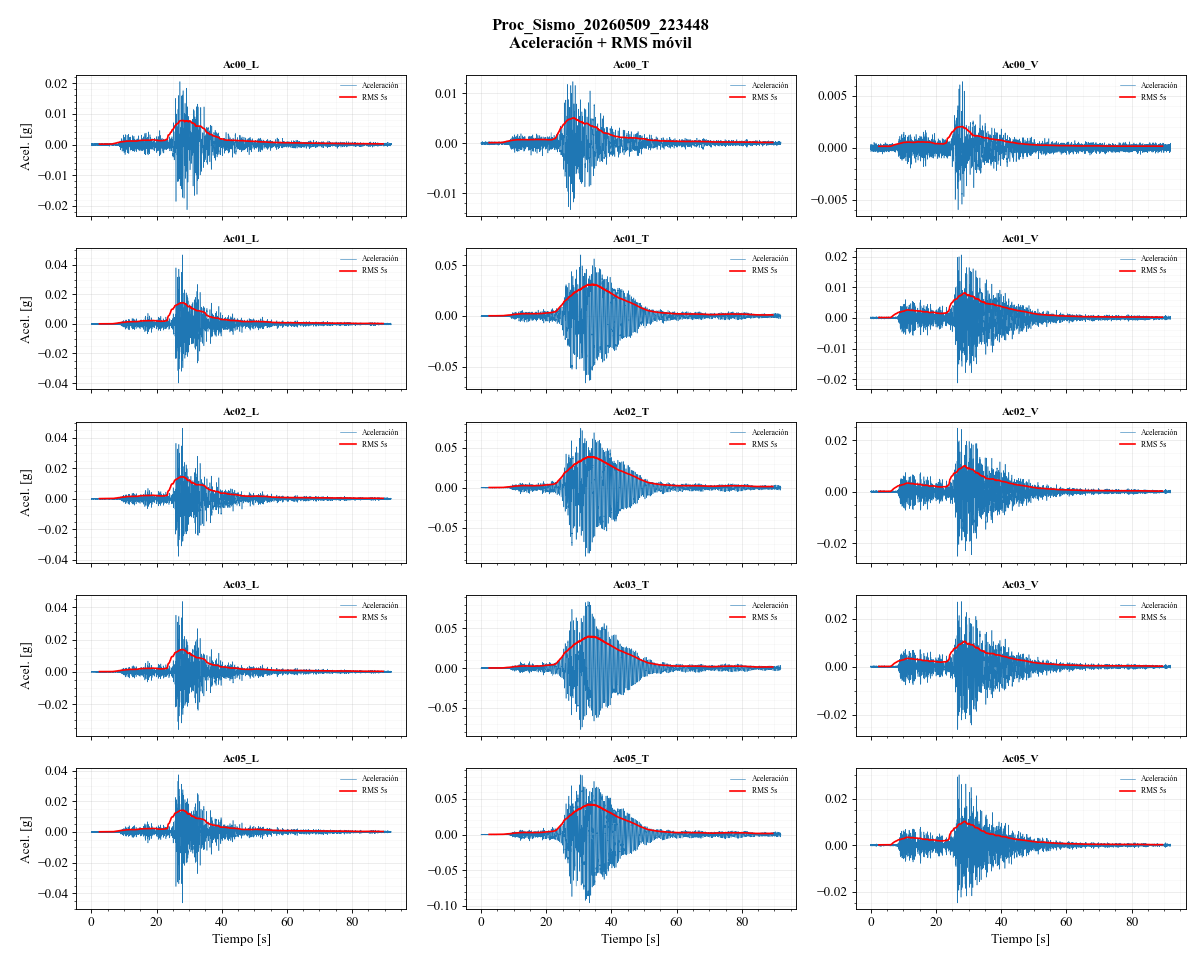

In [9]:
data = data_all[i]
name_data = data[:-4]
print(f'Registro escogido: {data}')
print(f'Nombre data: {name_data}')
df = pd.read_table(f'./{carpeta_data}/{data}', decimal=".")
plot_all_accel_rms(df,fs=fs,ventana_rms=5,name_data=name_data, COND=False)

In [10]:
# Si tienes una columna de tiempo, elimínala
df = df.iloc[:, 1:]

data = df.to_numpy(dtype=float)

2026-05-20 22:22:20,754 - pyoma2.setup.base - INFO - Running FDD... (base:123)
2026-05-20 22:22:20,896 - pyoma2.setup.base - INFO - all done (base:102)


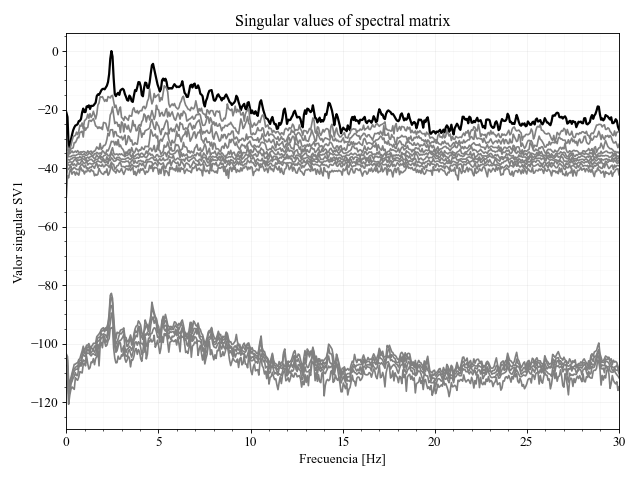

In [11]:
# =========================
# 2. Crear setup OMA
# =========================

setup = SingleSetup(data, fs=fs)

# =========================
# 3. Definir FDD
# =========================

fdd = FDD(name="FDD",nxseg=4096, method_SD="per")

setup.add_algorithms(fdd)
setup.run_all()

# =========================
# 4. Graficar CMIF / singular values
# =========================

fig, ax = fdd.plot_CMIF(freqlim=(0, 30))
plt.xlabel("Frecuencia [Hz]", fontsize=12)
plt.ylabel("Valor singular SV1", fontsize=12)
#plt.title(f'{carpeta_data}\nFDD - Frequency Domain Decomposition - {name_direc}', fontsize=14, fontweight='bold')
plt.grid(which="major", alpha=0.15)
plt.minorticks_on()
plt.grid(which="minor", alpha=0.05)
#plt.legend(loc=2, fontsize=4.5, ncol=1, frameon=False, bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()


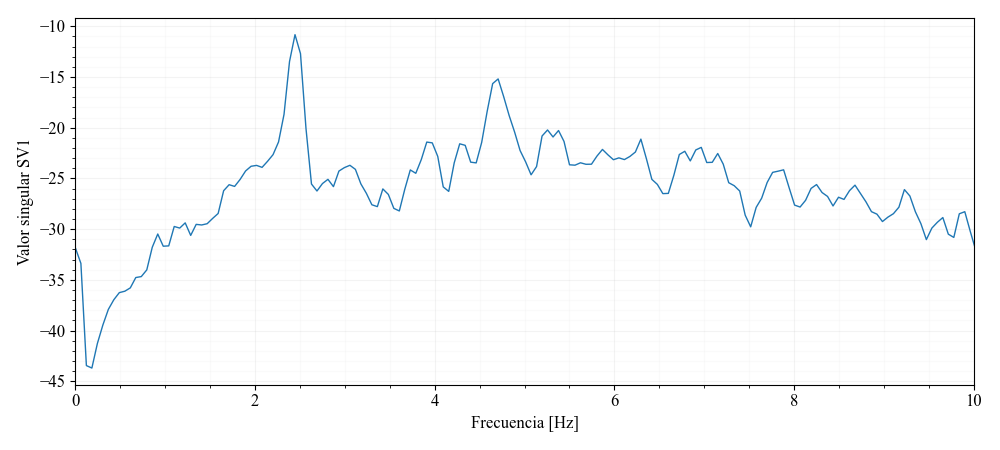

In [12]:
direccion = "ALL" #L:Longitudinal T:transversal V:vertical ALL:todas

if direccion == "ALL": canales = [col for col in df.columns if col != "t_s"]
else: canales = [f"Ac00_{direccion}",f"Ac01_{direccion}",f"Ac02_{direccion}",f"Ac03_{direccion}",f"Ac05_{direccion}",]

df_T = df[canales]
data_T = df_T.to_numpy()

setup = SingleSetup(data_T, fs=fs)

freq = fdd.result.freq
S_val = fdd.result.S_val

SV1 = S_val[0, 0, :]   # primera singular value

plt.figure(figsize=(10, 4.5), dpi=100)
plt.plot(freq, 10*np.log10(SV1), linewidth=1)
plt.xlim(0,10)
plt.xlabel("Frecuencia [Hz]", fontsize=12)
plt.ylabel("Valor singular SV1", fontsize=12)
#plt.title(f'{carpeta_data}\nFDD - Frequency Domain Decomposition - {name_direc}', fontsize=14, fontweight='bold')
plt.grid(which="major", alpha=0.15)
plt.minorticks_on()
plt.grid(which="minor", alpha=0.05)
#plt.legend(loc=2, fontsize=4.5, ncol=1, frameon=False, bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from pyoma2.setup import SingleSetup
from pyoma2.algorithms import EFDD

direccion = "ALL" #L:Longitudinal T:transversal V:vertical ALL:todas

if direccion == "ALL": canales = [col for col in df.columns if col != "t_s"]
else: canales = [f"Ac00_{direccion}",f"Ac01_{direccion}",f"Ac02_{direccion}",f"Ac03_{direccion}",f"Ac05_{direccion}",]

data = df[canales].to_numpy(dtype=float)

fs = 250

In [14]:
setup = SingleSetup(data, fs=fs)

efdd = EFDD(name="EFDD_T",nxseg=4096,method_SD="per")

setup.add_algorithms(efdd)
setup.run_all()

2026-05-20 22:22:21,649 - pyoma2.setup.base - INFO - Running EFDD_T... (base:123)
2026-05-20 22:22:21,797 - pyoma2.setup.base - INFO - all done (base:102)


In [15]:
freq_candidatas = [2.448, 4.68, 6.28]

efdd.mpe(sel_freq=freq_candidatas,MAClim=0.00000000000000008)

Fn = efdd.result.Fn
Xi = efdd.result.Xi
Phi = efdd.result.Phi

for i, f in enumerate(Fn):
    print(f"Modo {i+1}")
    print(f"Fn = {f:.4f} Hz")
    print(f"Xi = {Xi[i]*100:.3f} %")
    print()

2026-05-20 22:22:21,911 - pyoma2.functions.fdd - INFO - Extracting FDD modal parameters (fdd:287)
100%|██████████| 3/3 [00:00<?, ?it/s]
2026-05-20 22:22:22,101 - pyoma2.functions.fdd - INFO - EFDD extraction complete. (fdd:567)


Modo 1
Fn = 2.4542 Hz
Xi = 1.701 %

Modo 2
Fn = 4.6858 Hz
Xi = 1.940 %

Modo 3
Fn = 6.5265 Hz
Xi = 3.352 %



In [16]:
import numpy as np
import matplotlib.pyplot as plt

from pyoma2.setup.single import SingleSetup
from pyoma2.algorithms import SSI

In [17]:
direccion = "ALL" #L:Longitudinal T:transversal V:vertical ALL:todas

if direccion == "ALL": canales = [col for col in df.columns if col != "t_s"]
else: canales = [f"Ac00_{direccion}",f"Ac01_{direccion}",f"Ac02_{direccion}",f"Ac03_{direccion}",f"Ac05_{direccion}",]

data = df[canales].to_numpy(dtype=float)

fs = 250

In [26]:
# =========================
# 2. Setup SSI
# =========================

setup = SingleSetup(data, fs=fs)

ssi = SSI(
    name="SSI",
    br=50,        # block rows
    ordmax=120    # orden máximo del modelo
)

setup.add_algorithms(ssi)
setup.run_all()

# =========================
# 3. Diagrama de estabilización
# =========================

# ssi.plot_stab(freqlim=(0, 10))
# plt.show()

freq_candidatas = [2.44]

ssi.mpe(sel_freq=freq_candidatas,)

Fn = ssi.result.Fn
Xi = ssi.result.Xi

for i, f in enumerate(Fn):
    print(f"Modo {i+1}")
    print(f"Fn = {f:.4f} Hz")
    print(f"Xi = {Xi[i]*100:.3f} %")
    print()

2026-05-20 22:23:12,935 - pyoma2.setup.base - INFO - Running SSI... (base:123)
2026-05-20 22:23:12,935 - pyoma2.functions.ssi - INFO - Assembling Hankel matrix method: cov... (ssi:91)
2026-05-20 22:23:13,293 - pyoma2.functions.ssi - INFO - SSI for increasing model order... (ssi:464)
100%|██████████| 121/121 [00:00<00:00, 246.35it/s]
2026-05-20 22:23:13,794 - pyoma2.functions.ssi - INFO - Calculating modal parameters for increasing model order... (ssi:630)
100%|██████████| 121/121 [00:00<00:00, 353.75it/s]
2026-05-20 22:23:14,624 - pyoma2.setup.base - INFO - all done (base:102)
2026-05-20 22:23:14,625 - pyoma2.functions.ssi - INFO - Extracting SSI modal parameters (ssi:1038)


Modo 1
Fn = 2.4382 Hz
Xi = 0.460 %



In [19]:
Fn

array([], dtype=float64)